# Compare Multiple DPLM Runs by EnzymeExplorer isTPS Metrics

This notebook loads multiple DPLM training runs, extracts EnzymeExplorer `isTPS` scores for each step, and summarizes the best-performing steps by mean and median isTPS. Tables and plots are generated for easy comparison.

**Instructions:**
- In the next cell, edit the list of `train.log` paths for the runs you want to compare.
- All downstream analysis will be performed automatically for each run.

In [3]:
# --- 1. Define Run Inputs and Output Paths ---
from pathlib import Path

# User: Edit this dictionary to include all runs you want to compare
# Keys are run labels, values are absolute paths to train.log files
run_logs = {
    "run_20": "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_run_20_lr1em4_wu200_ts20000_ckpt1000_valee1000_lend1em05_winit1em07_loratrue/train.log",
    "run_29": "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_run_29_lr1em4_wu200_ts20000_ckpt1000_valee1000_lend1em05_winit1em07_loratrue/train.log",
    "run_30": "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_run_30_lr1em4_wu200_ts20000_ckpt1000_valee1000_lend1em05_winit1em07_loratrue/train.log",
    "run_31": "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_run_31_lr1em4_wu200_ts20000_ckpt1000_valee1000_lend1em05_winit1em07_loratrue/train.log",
    "run_32": "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_run_32_lr1em4_wu200_ts20000_ckpt1000_valee1000_lend1em05_winit1em07_loratrue/train.log",
    "run_33": "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_run_33_lr1em4_wu200_ts20000_ckpt1000_valee1000_lend1em05_winit1em07_loratrue/train.log",
}

# Output directory for combined results
output_dir = Path("/Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {output_dir}")
print(f"Runs loaded: {list(run_logs.keys())}")

Output directory: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison
Runs loaded: ['run_20', 'run_29', 'run_30', 'run_31', 'run_32', 'run_33']


In [4]:
# --- 2. Import Libraries and Shared Parsing Utilities ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Utility: Robust isTPS column name matching
TARGET_COLUMN_NAME = "isTPS"
def find_isTPS_column(columns):
    # Accepts trailing spaces and case-insensitive
    for col in columns:
        if col.strip().lower() == TARGET_COLUMN_NAME.lower():
            return col
    return None

# Utility: Identify step folders (step_N, sanity_check_step_0)
def get_step_folders(enzyme_explorer_path):
    folders = []
    if not enzyme_explorer_path.exists():
        return folders
    # Add sanity_check_step_0 if present
    sanity = enzyme_explorer_path / "sanity_check_step_0"
    if sanity.exists() and sanity.is_dir():
        folders.append(sanity)
    # Add all step_N folders
    folders += sorted([
        f for f in enzyme_explorer_path.iterdir()
        if f.is_dir() and f.name.startswith("step_") and f.name.split("_")[-1].isdigit()
    ], key=lambda f: int(f.name.split("_")[-1]))
    return folders

In [5]:
# --- 3. Collect EnzymeExplorer isTPS Values per Step for Each Run ---
all_rows = []
for run_name, log_path in run_logs.items():
    log_path = Path(log_path)
    enzyme_explorer_path = log_path.parent / "enzyme_explorer_validation"
    step_folders = get_step_folders(enzyme_explorer_path)
    for step_folder in step_folders:
        step_name = step_folder.name
        # Extract numeric step index for sorting (sanity_check_step_0 = 0)
        if step_name.startswith("sanity_check_step_0"):
            step_index = 0
        else:
            try:
                step_index = int(step_name.split("_")[-1])
            except Exception:
                step_index = np.nan
        # Aggregate all CSVs in this step folder
        csv_files = list(step_folder.glob("*.csv"))
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
            except Exception as e:
                print(f"Error reading {csv_file}: {e}")
                continue
            col = find_isTPS_column(df.columns)
            if col is None:
                print(f"No isTPS column in {csv_file}")
                continue
            values = pd.to_numeric(df[col], errors="coerce").dropna()
            for v in values:
                all_rows.append({
                    "run_name": run_name,
                    "step_name": step_name,
                    "step_index": step_index,
                    "isTPS": v
                })

# Build long-form DataFrame
all_isTPS_df = pd.DataFrame(all_rows)
print(f"Loaded {len(all_isTPS_df)} isTPS values from all runs.")
display(all_isTPS_df.head())

Loaded 6300 isTPS values from all runs.


,run_name,step_name,step_index,isTPS
0,run_20,sanity_check_step_0,0,0.369737
1,run_20,sanity_check_step_0,0,0.347949
2,run_20,sanity_check_step_0,0,0.161959
3,run_20,sanity_check_step_0,0,0.394023
4,run_20,sanity_check_step_0,0,0.025570


In [6]:
# --- 4. Compute Step-Level Mean and Median isTPS per Run ---
if not all_isTPS_df.empty:
    step_stats = (
        all_isTPS_df
        .groupby(["run_name", "step_name", "step_index"], as_index=False)
        .agg(n_sequences=("isTPS", "count"), mean_isTPS=("isTPS", "mean"), median_isTPS=("isTPS", "median"))
        .sort_values(["run_name", "step_index"])
    )
    display(step_stats.head(10))
else:
    print("No isTPS values found in any run.")

,run_name,step_name,step_index,n_sequences,mean_isTPS,median_isTPS
0,run_20,sanity_check_step_0,0,50,0.259169,0.356836
1,run_20,step_1000,1000,50,0.319327,0.253068
12,run_20,step_2000,2000,50,0.633314,0.780281
14,run_20,step_3000,3000,50,0.667788,0.820761
15,run_20,step_4000,4000,50,0.473648,0.296699
16,run_20,step_5000,5000,50,0.469639,0.328466
17,run_20,step_6000,6000,50,0.770969,0.861097
18,run_20,step_7000,7000,50,0.531842,0.752116
19,run_20,step_8000,8000,50,0.768035,0.859599
20,run_20,step_9000,9000,50,0.596660,0.715228


In [7]:
# --- 5. Select Best Step by Median and Best Step by Mean ---
if not all_isTPS_df.empty:
    best_by_median = (
        step_stats.loc[step_stats.groupby("run_name")["median_isTPS"].idxmax()]
        .sort_values("run_name")
        .rename(columns={"step_name": "best_median_step", "median_isTPS": "best_median_score", "n_sequences": "n_sequences_at_best_median"})
    )
    best_by_mean = (
        step_stats.loc[step_stats.groupby("run_name")["mean_isTPS"].idxmax()]
        .sort_values("run_name")
        .rename(columns={"step_name": "best_mean_step", "mean_isTPS": "best_mean_score", "n_sequences": "n_sequences_at_best_mean"})
    )
    # Merge for summary
    summary = pd.merge(
        best_by_median[["run_name", "best_median_score", "best_median_step", "n_sequences_at_best_median"]],
        best_by_mean[["run_name", "best_mean_score", "best_mean_step", "n_sequences_at_best_mean"]],
        on="run_name",
        how="outer"
    )
    display(summary)
else:
    print("No isTPS values found in any run.")

,run_name,best_median_score,best_median_step,n_sequences_at_best_median,best_mean_score,best_mean_step,n_sequences_at_best_mean
0,run_20,0.881094,step_12000,50,0.866231,step_12000,50
1,run_29,0.786278,step_20000,50,0.722441,step_16000,50
2,run_30,0.825103,step_12000,50,0.780183,step_12000,50
3,run_31,0.828195,step_20000,50,0.794150,step_20000,50
4,run_32,0.836600,step_19000,50,0.765457,step_16000,50
5,run_33,0.836280,step_19000,50,0.805555,step_15000,50


In [8]:
# --- 6. Build Summary DataFrames for All Runs ---
if not all_isTPS_df.empty:
    # Table 1: Scores only
    score_table = summary[["run_name", "best_median_score", "best_mean_score"]].copy()
    score_table.to_csv(output_dir / "best_scores_summary.csv", index=False)
    print(f"Saved: {output_dir / 'best_scores_summary.csv'}")
    display(score_table)

    # Table 2: Best step names and sequence counts
    step_table = summary[[
        "run_name", "best_median_step", "n_sequences_at_best_median", "best_mean_step", "n_sequences_at_best_mean"
    ]].copy()
    step_table.to_csv(output_dir / "best_steps_summary.csv", index=False)
    print(f"Saved: {output_dir / 'best_steps_summary.csv'}")
    display(step_table)
else:
    print("No summary tables to display.")

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/best_scores_summary.csv


,run_name,best_median_score,best_mean_score
0,run_20,0.881094,0.866231
1,run_29,0.786278,0.722441
2,run_30,0.825103,0.780183
3,run_31,0.828195,0.794150
4,run_32,0.836600,0.765457
5,run_33,0.836280,0.805555


Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/best_steps_summary.csv


,run_name,best_median_step,n_sequences_at_best_median,best_mean_step,n_sequences_at_best_mean
0,run_20,step_12000,50,step_12000,50
1,run_29,step_20000,50,step_16000,50
2,run_30,step_12000,50,step_12000,50
3,run_31,step_20000,50,step_20000,50
4,run_32,step_19000,50,step_16000,50
5,run_33,step_19000,50,step_15000,50


Saved table figure: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/best_scores_summary.png


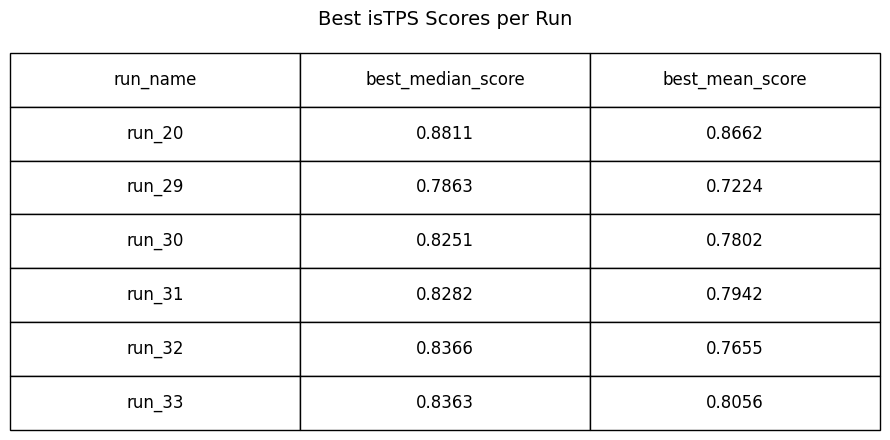

Saved table figure: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/best_steps_summary.png


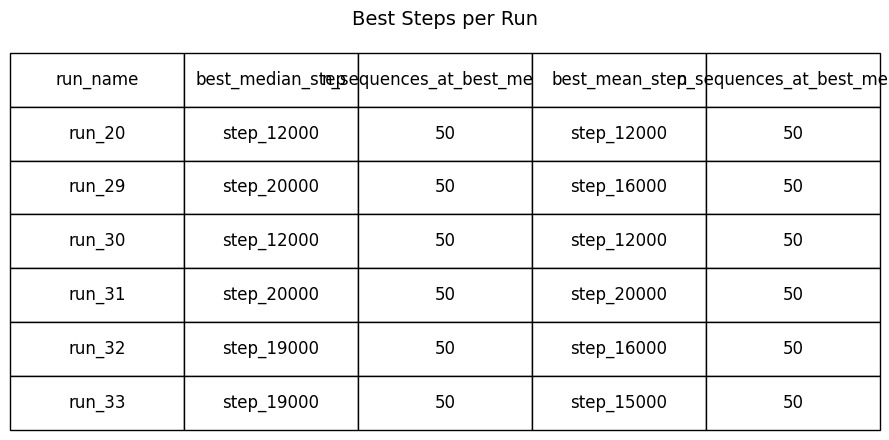

In [9]:
# --- 7. Render and Save Summary Tables as Figures and CSV ---
def render_table_as_figure(df, title, filename):
    fig, ax = plt.subplots(figsize=(max(6, len(df) * 1.5), 1.5 + 0.5 * len(df)))
    ax.axis('off')
    tbl = ax.table(
        cellText=df.round(4).values,
        colLabels=df.columns,
        loc='center',
        cellLoc='center',
        colLoc='center',
        bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(12)
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200, bbox_inches='tight')
    print(f"Saved table figure: {output_dir / filename}")
    plt.show()

if not all_isTPS_df.empty:
    render_table_as_figure(score_table, "Best isTPS Scores per Run", "best_scores_summary.png")
    render_table_as_figure(step_table, "Best Steps per Run", "best_steps_summary.png")

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/run_20_isTPS_by_step.png


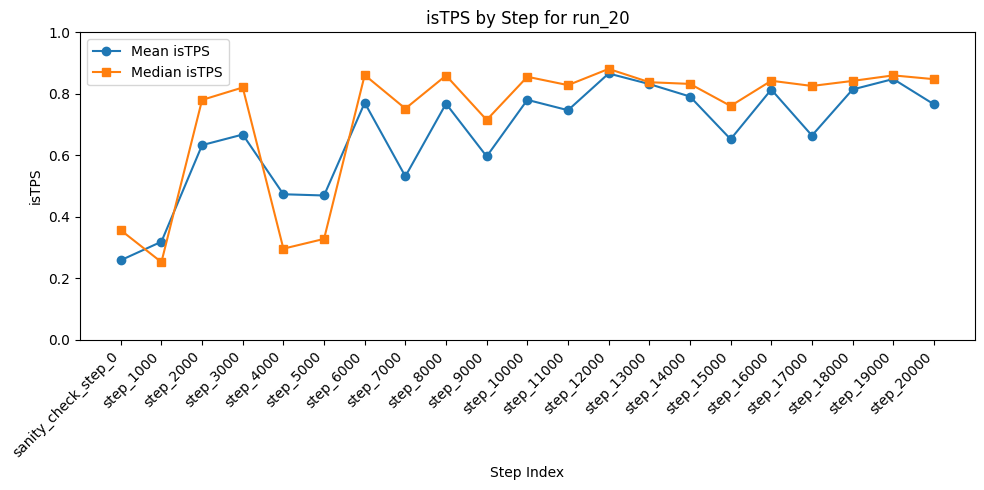

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/run_29_isTPS_by_step.png


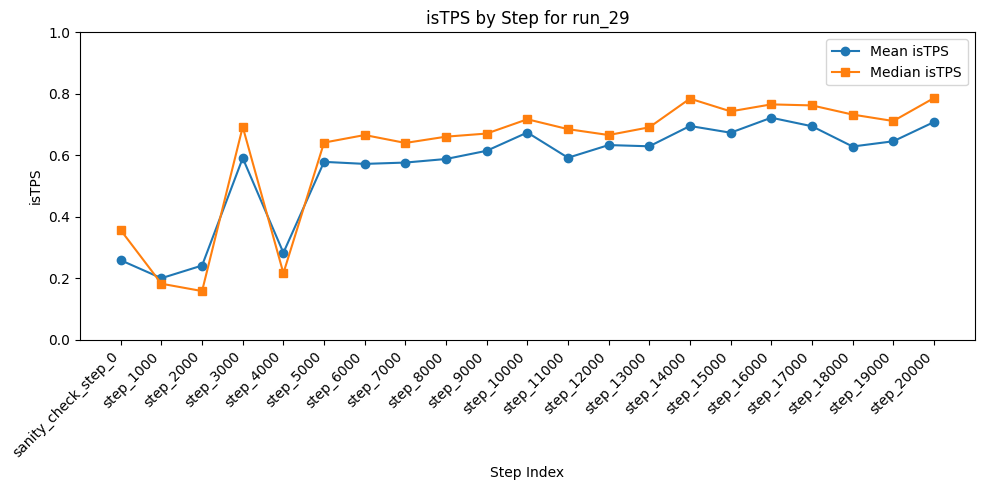

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/run_30_isTPS_by_step.png


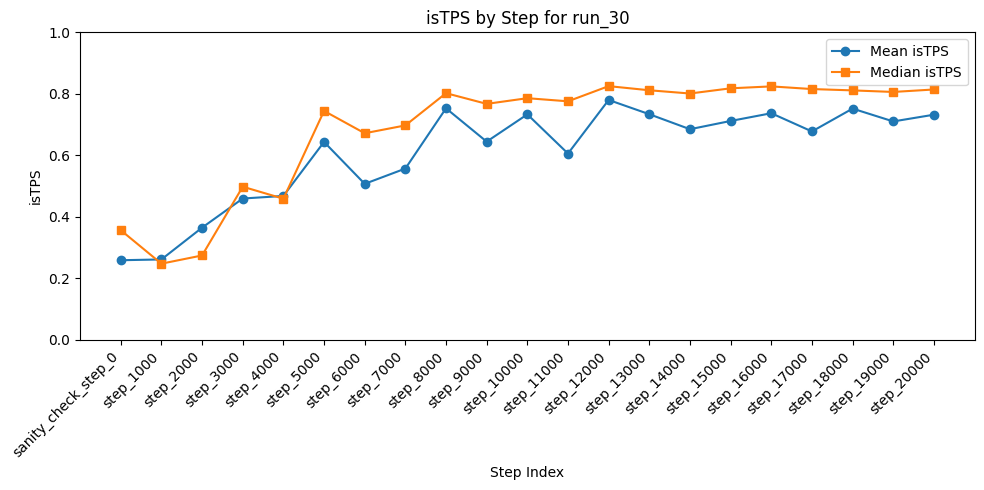

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/run_31_isTPS_by_step.png


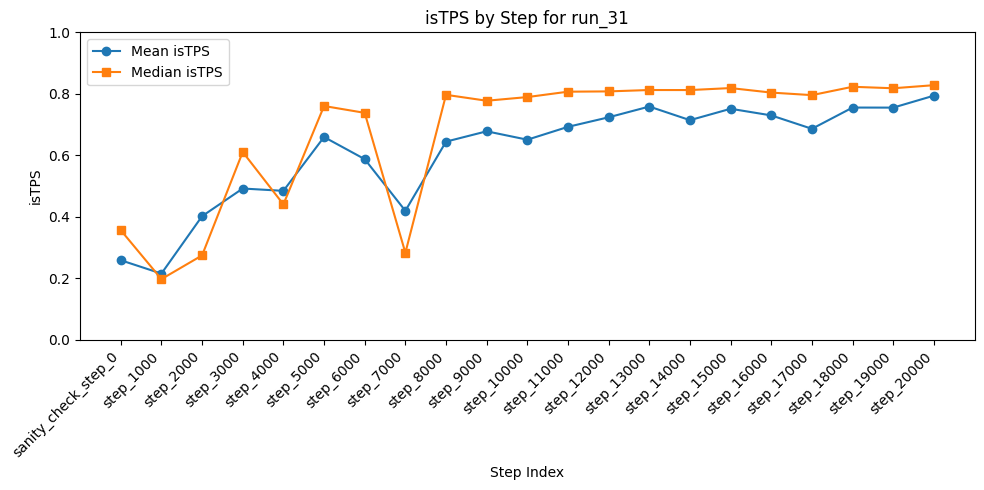

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/run_32_isTPS_by_step.png


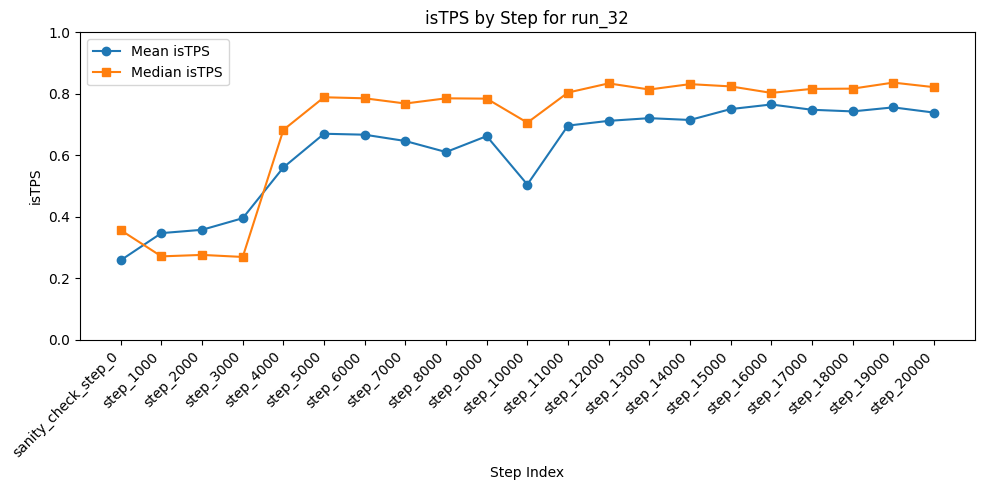

Saved: /Volumes/data/Users/Matous/terpene_synthases/output/dplm/comparison/layers_comparison/run_33_isTPS_by_step.png


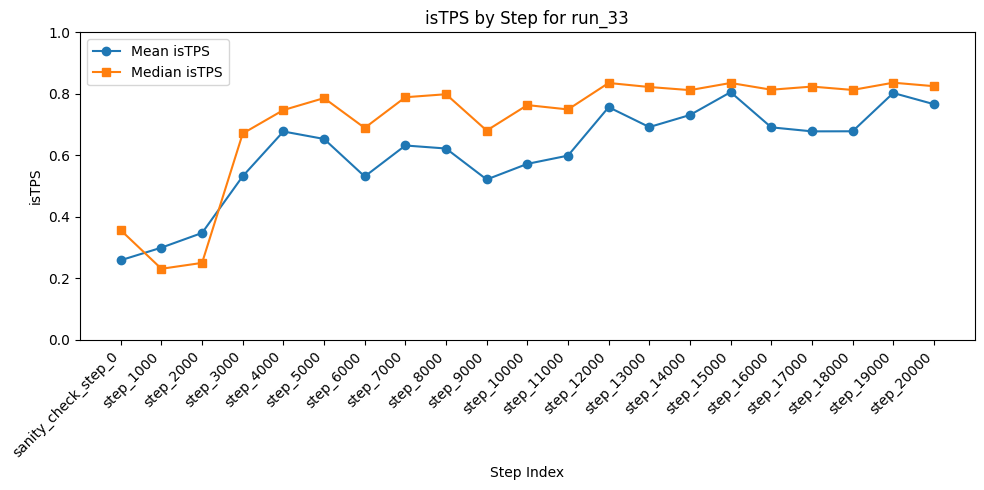

In [10]:
# --- 8. Optional: Per-Run Diagnostic Plot of Mean/Median by Step ---
if not all_isTPS_df.empty:
    for run_name, group in step_stats.groupby("run_name"):
        plt.figure(figsize=(10, 5))
        plt.plot(group["step_index"], group["mean_isTPS"], marker="o", label="Mean isTPS")
        plt.plot(group["step_index"], group["median_isTPS"], marker="s", label="Median isTPS")
        plt.title(f"isTPS by Step for {run_name}")
        plt.xlabel("Step Index")
        plt.ylabel("isTPS")
        plt.ylim(0, 1)
        plt.xticks(group["step_index"], group["step_name"], rotation=45, ha="right")
        plt.legend()
        plt.tight_layout()
        fname = output_dir / f"{run_name}_isTPS_by_step.png"
        plt.savefig(fname, dpi=200, bbox_inches="tight")
        print(f"Saved: {fname}")
        plt.show()